# CSE440 NLP Project Notebook
## Multi-Class Text Classification: Outline, EDA, Preprocessing, and Experiment Pipeline

This notebook is structured to match the project brief:
- extensive EDA
- three preprocessing variants
- TF-IDF with one ML model and one deep neural network
- Skip-gram with all required sequence models
- accuracy, macro F1, confusion matrix, and classification report
- comparison of best and worst settings

This version is built from the files available in the workspace:
- `Training_data_4.csv`
- `Test_data.csv`
- `Spring 2026 - CSE440 Lab Project.pdf`

I did **not** find the actual CSE440 lab1/lab2/lab3 NLP reference files in the current workspace. I only found the project PDF plus the train/test CSVs, so the notebook below is aligned to the project requirements and the dataset itself.

## Recommended workflow

1. Inspect the raw train/test files and verify shapes, labels, missing values, and artifacts.
2. Do EDA on the training set first, then compare train vs test distributions only at a high level.
3. Build three text versions:
   - no preprocessing
   - extreme preprocessing
   - optimum preprocessing chosen from EDA
4. Keep the test set untouched until final evaluation.
5. Create a validation split from the training set only.
6. Run TF-IDF experiments with:
   - one ML model
   - one deep neural network
7. Run Skip-gram experiments with:
   - SimpleRNN
   - GRU
   - LSTM
   - Bidirectional SimpleRNN
   - Bidirectional GRU
   - Bidirectional LSTM
8. Log every tuning run in a results table.
9. Retrain the best validation setting on the full training set.
10. Evaluate once on the test set and write the report.

## Suggested group workflow

- Person 1: EDA + preprocessing analysis + report figures
- Person 2: TF-IDF + ML + DNN tuning
- Person 3: Skip-gram + sequence model tuning
- Everyone: final comparison table, report writing, and viva preparation

## Optional setup cell

In [1]:
%pip install -q beautifulsoup4 wordcloud gensim nltk tensorflow

Note: you may need to restart the kernel to use updated packages.


## Imports and reproducibility

In [2]:
import os
import re
import html
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import tensorflow as tf

from bs4 import BeautifulSoup
from collections import Counter
from wordcloud import WordCloud
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD

from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional, SpatialDropout1D

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", 100)

nltk.download("punkt")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("figures", exist_ok=True)
os.makedirs("logs", exist_ok=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Load the assigned train and test files

In [3]:
TRAIN_PATH = "Training_data_4.csv"
TEST_PATH = "Test_data.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(test_df.shape)
train_df.head()

(104763, 2)
(12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology
3,<html> <body> News Headlines:\r\n <br> <b> U.S. Trade Deficit Swells to Record #36;55.5B (AP) AP - America's trade deficit swelled to an all-time high of #36;55.5 billion in October as imports #151; including those from China #151; surged to the loftiest levels on record. Skyrocketing crude-...,Business
4,"<html> <body> News Headlines:\r\n <br> <b> Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion compani...",Business


## Dataset overview

In [4]:
overview_df = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "missing_text": [train_df["News Headline"].isna().sum(), test_df["News Headline"].isna().sum()],
    "missing_label": [train_df["News Topic"].isna().sum(), test_df["News Topic"].isna().sum()],
    "unique_raw_texts": [train_df["News Headline"].nunique(), test_df["News Headline"].nunique()],
    "duplicate_rows": [train_df.duplicated().sum(), test_df.duplicated().sum()]
})
overview_df

,split,rows,missing_text,missing_label,unique_raw_texts,duplicate_rows
0,train,104763,0,0,73555,31208
1,test,12000,0,0,12000,0


## Class distribution table

In [5]:
train_label_dist = train_df["News Topic"].value_counts().rename("train_count").to_frame()
train_label_dist["train_pct"] = (train_label_dist["train_count"] / len(train_df) * 100).round(2)

test_label_dist = test_df["News Topic"].value_counts().rename("test_count").to_frame()
test_label_dist["test_pct"] = (test_label_dist["test_count"] / len(test_df) * 100).round(2)

label_dist_df = train_label_dist.join(test_label_dist, how="outer")
label_dist_df

,train_count,train_pct,test_count,test_pct
News Topic,,,,
Business,18563,17.72,3000,25.0
Science and Technology,36428,34.77,3000,25.0
Sports,34178,32.62,3000,25.0
World News,15594,14.89,3000,25.0


## Class distribution plot

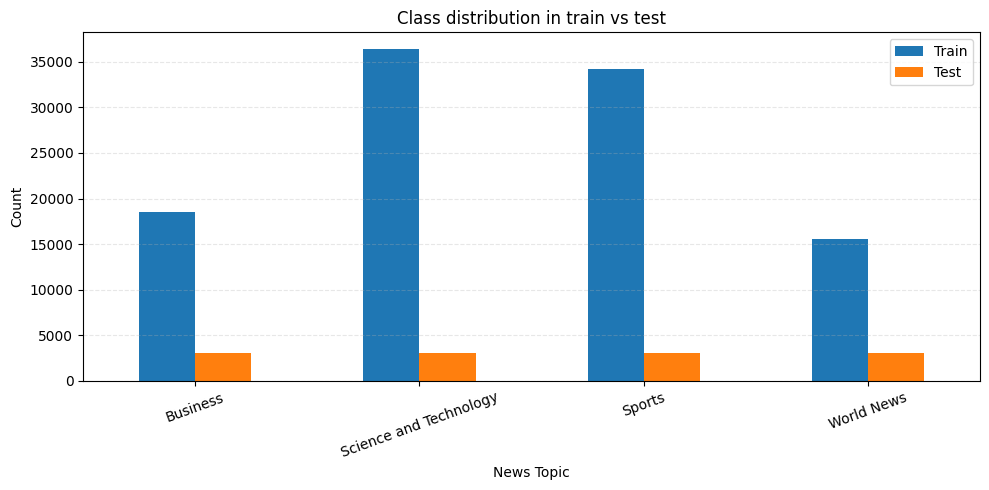

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = pd.DataFrame({
    "Train": train_df["News Topic"].value_counts(),
    "Test": test_df["News Topic"].value_counts()
}).fillna(0)

plot_df.plot(kind="bar", ax=ax)
ax.set_title("Class distribution in train vs test")
ax.set_xlabel("News Topic")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Raw sample inspection

In [7]:
sample_view = train_df.sample(5, random_state=SEED)[["News Topic", "News Headline"]]
sample_view

,News Topic,News Headline
7339,Science and Technology,<html> <body> News Headlines:\r\n <br> <b> IBM scores \$1B in Danish contracts IBM announced agreements with two Danish companies on outsourcing deals that together are worth more than \$1 billion over 10 years. </b> \r\n <br> <br>
69095,Science and Technology,"<html> <body> News Headlines:\r\n <br> <b> REVIEW: Kit Automates Holiday Lights (AP) AP - It's a chore that can quickly chill the warmth of the holiday season: Trudging outside each winter night to unplug the lights, deflate the blowup snowman and shut off the rest of the outdoor extravaganza. <..."
73557,Science and Technology,"<html> <body> News Headlines:\r\n <br> <b> Education Helping Seniors Get Online (AP) AP - Wadia Bajoka, a 71-year-old Iraqi immigrant, enjoys knitting, gardening, and baking pungent meat pies that she presents to guests in an old-fashioned display of hospitality. </b> \r\n <br> <br>"
66592,Science and Technology,"<html> <body> News Headlines:\r\n <br> <b> Is there a future for the 1Gig email services? We all remember April 1st when Google announced its new Gmail web-mail service with an overwhelming 1Gig storage space. Their mere announcement brought a new wave of 1Gig web-mail services such as Walla , ..."
35404,World News,"<html> <body> News Headlines:\r\n <br> <b> Electricity Goes Off Across Bahrain (AP) AP - Electricity went out across Bahrain on Monday, leaving people without air conditioning on a day when temperatures were expected to reach 130, snarling rush hour traffic and sending businesses and the U.S. Na..."


## Cleaning helpers for EDA

In [8]:
ENTITY_REPLACEMENTS = {
    r"#39;": "'",
    r"#146;": "'",
    r"quot;": '"',
    r"amp;": "&",
    r"#151;": "-",
    r"#36;": "$",
    r"&lt;": "<",
    r"&gt;": ">"
}

def normalize_artifacts(text):
    text = str(text)
    for pattern, replacement in ENTITY_REPLACEMENTS.items():
        text = re.sub(pattern, replacement, text)
    text = text.replace("\\", " ")
    return text

def basic_eda_clean(text):
    text = normalize_artifacts(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ", strip=True)
    text = html.unescape(text)
    text = re.sub(r"^\s*News Headlines:\s*", "", text, flags=re.I)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, test_df]:
    df["text_eda"] = df["News Headline"].apply(basic_eda_clean)
    df["char_len"] = df["text_eda"].str.len()
    df["word_len"] = df["text_eda"].str.count(r"\b\w+\b")
    df["has_digit"] = df["text_eda"].str.contains(r"\d")
    df["has_parentheses"] = df["text_eda"].str.contains(r"[()]")
    df["has_hyphen"] = df["text_eda"].str.contains(r"-")
    df["has_quote"] = df["text_eda"].str.contains(r"['\"]")
    df["has_backslash"] = df["News Headline"].str.contains(r"\\")
    df["has_html_tags"] = df["News Headline"].str.contains(r"<html>|<body>|<br>|<b>", regex=True)
    df["has_broken_entities"] = df["News Headline"].str.contains(r"#39;|quot;|amp;|#151;|#36;|&lt;|&gt;", regex=True)
    df["starts_with_news_headlines"] = df["News Headline"].str.contains("News Headlines:", regex=False)

train_df[["News Topic", "text_eda"]].head()

,News Topic,text_eda
0,World News,Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region.
1,Science and Technology,"Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday said it had revised its proposal to weed out ""spam"" e-mail to win over skeptical Internet engineers who have been reluctant to adopt technology owned by the dominant software company."
2,Science and Technology,"Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died."
3,Business,U.S. Trade Deficit Swells to Record $55.5B (AP) AP - America's trade deficit swelled to an all-time high of $55.5 billion in October as imports - including those from China - surged to the loftiest levels on record. Skyrocketing crude-oil prices also contributed to the yawning trade gap.
4,Business,"Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion companies from major construction projects in the ..."


## Data-quality summary

In [9]:
quality_df = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "missing_label",
        "unique_raw_texts",
        "duplicate_rows",
        "avg_words",
        "median_words",
        "avg_chars",
        "median_chars",
        "has_html_tags_pct",
        "has_broken_entities_pct",
        "has_backslash_pct",
        "starts_with_news_headlines_pct"
    ],
    "train": [
        len(train_df),
        train_df["News Headline"].isna().sum(),
        train_df["News Topic"].isna().sum(),
        train_df["News Headline"].nunique(),
        train_df.duplicated().sum(),
        round(train_df["word_len"].mean(), 2),
        int(train_df["word_len"].median()),
        round(train_df["char_len"].mean(), 2),
        int(train_df["char_len"].median()),
        round(train_df["has_html_tags"].mean() * 100, 2),
        round(train_df["has_broken_entities"].mean() * 100, 2),
        round(train_df["has_backslash"].mean() * 100, 2),
        round(train_df["starts_with_news_headlines"].mean() * 100, 2)
    ],
    "test": [
        len(test_df),
        test_df["News Headline"].isna().sum(),
        test_df["News Topic"].isna().sum(),
        test_df["News Headline"].nunique(),
        test_df.duplicated().sum(),
        round(test_df["word_len"].mean(), 2),
        int(test_df["word_len"].median()),
        round(test_df["char_len"].mean(), 2),
        int(test_df["char_len"].median()),
        round(test_df["has_html_tags"].mean() * 100, 2),
        round(test_df["has_broken_entities"].mean() * 100, 2),
        round(test_df["has_backslash"].mean() * 100, 2),
        round(test_df["starts_with_news_headlines"].mean() * 100, 2)
    ]
})
quality_df

,metric,train,test
0,rows,104763.00,12000.00
1,missing_text,0.00,0.00
2,missing_label,0.00,0.00
3,unique_raw_texts,73555.00,12000.00
4,duplicate_rows,31208.00,0.00
5,avg_words,38.38,38.46
6,median_words,38.00,38.00
7,avg_chars,229.42,230.70
8,median_chars,226.00,229.00
9,has_html_tags_pct,100.00,100.00


## Duplicate analysis

In [10]:
dup_df = train_df.assign(dup_any=train_df["News Headline"].duplicated(keep=False)).groupby("News Topic").agg(
    total=("News Headline", "size"),
    dup_rows=("dup_any", "sum"),
    repeated_beyond_first=("News Headline", lambda s: int(s.duplicated().sum()))
).reset_index()

dup_df["dup_row_pct"] = (dup_df["dup_rows"] / dup_df["total"] * 100).round(2)
dup_df["unique_texts"] = dup_df["total"] - dup_df["repeated_beyond_first"]
dup_df

,News Topic,total,dup_rows,repeated_beyond_first,dup_row_pct,unique_texts
0,Business,18563,0,0,0.00,18563
1,Science and Technology,36428,27010,16424,74.15,20004
2,Sports,34178,24543,14784,71.81,19394
3,World News,15594,0,0,0.00,15594


## Length and class-wise statistics

In [11]:
length_stats_df = train_df.groupby("News Topic").agg(
    count=("text_eda", "size"),
    avg_words=("word_len", "mean"),
    median_words=("word_len", "median"),
    avg_chars=("char_len", "mean"),
    median_chars=("char_len", "median"),
    digits_pct=("has_digit", "mean"),
    parentheses_pct=("has_parentheses", "mean"),
    hyphen_pct=("has_hyphen", "mean"),
    quote_pct=("has_quote", "mean"),
    broken_entities_pct=("has_broken_entities", "mean")
).reset_index()

for col in length_stats_df.columns:
    if col.endswith("_pct"):
        length_stats_df[col] = (length_stats_df[col] * 100).round(2)
    elif col not in ["News Topic", "count"]:
        length_stats_df[col] = length_stats_df[col].round(2)

length_stats_df

,News Topic,count,avg_words,median_words,avg_chars,median_chars,digits_pct,parentheses_pct,hyphen_pct,quote_pct,broken_entities_pct
0,Business,18563,38.29,38.0,230.75,232.0,50.90,36.20,60.22,42.28,38.35
1,Science and Technology,36428,38.05,37.0,231.59,227.0,38.61,28.55,59.73,43.69,28.65
2,Sports,34178,38.36,37.0,221.59,216.0,52.49,25.26,67.10,48.02,35.79
3,World News,15594,39.34,39.0,239.88,240.0,34.27,34.14,63.11,46.10,25.04


## Word-count distribution

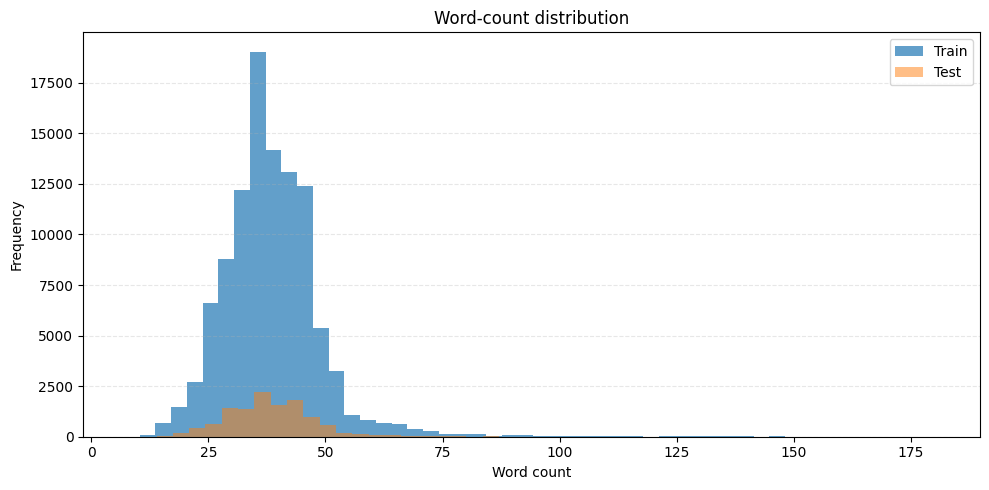

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df["word_len"], bins=50, alpha=0.7, label="Train")
ax.hist(test_df["word_len"], bins=50, alpha=0.5, label="Test")
ax.set_title("Word-count distribution")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Word-count by class

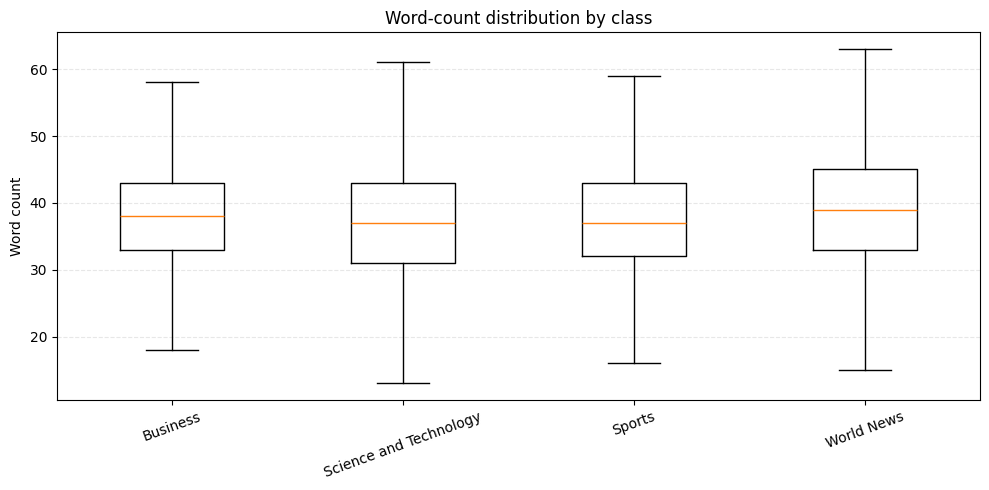

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered_topics = sorted(train_df["News Topic"].unique())
box_data = [train_df.loc[train_df["News Topic"] == topic, "word_len"] for topic in ordered_topics]
ax.boxplot(box_data, labels=ordered_topics, showfliers=False)
ax.set_title("Word-count distribution by class")
ax.set_ylabel("Word count")
plt.xticks(rotation=20)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Source-tag frequency by class

In [14]:
source_df = []
for topic, subset in train_df.groupby("News Topic"):
    source_df.append({
        "News Topic": topic,
        "Reuters_pct": round(subset["text_eda"].str.contains(r"\bReuters\b").mean() * 100, 2),
        "AP_pct": round(subset["text_eda"].str.contains(r"\bAP\b").mean() * 100, 2),
        "AFP_pct": round(subset["text_eda"].str.contains(r"\bAFP\b").mean() * 100, 2)
    })

source_df = pd.DataFrame(source_df)
source_df

,News Topic,Reuters_pct,AP_pct,AFP_pct
0,Business,18.90,0.93,1.09
1,Science and Technology,6.68,6.88,0.68
2,Sports,4.67,10.35,0.51
3,World News,13.10,10.35,6.16


## Most common unigrams after removing source tags

In [15]:
def remove_source_tags(text):
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_no_source"] = train_df["text_eda"].apply(remove_source_tags)

def get_top_ngrams(texts, ngram_range=(1, 1), top_n=15):
    vectorizer = CountVectorizer(lowercase=True, stop_words="english", ngram_range=ngram_range, min_df=5)
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"term": terms[order], "count": counts[order]})

top_unigrams = {topic: get_top_ngrams(group["text_no_source"], (1, 1), 12) for topic, group in train_df.groupby("News Topic")}
top_bigrams = {topic: get_top_ngrams(group["text_no_source"], (2, 2), 12) for topic, group in train_df.groupby("News Topic")}

top_unigrams["Science and Technology"]

,term,count
0,new,8660
1,microsoft,6231
2,said,4622
3,software,4400
4,internet,4158
5,company,3578
6,space,3262
7,search,2828
8,security,2756
9,web,2649


## Most common bigrams after removing source tags

In [16]:
top_bigrams["Sports"]

,term,count
0,new york,1911
1,red sox,1673
2,sports network,1461
3,world cup,1016
4,united states,637
5,gold medal,625
6,manchester united,619
7,los angeles,578
8,champions league,570
9,ryder cup,566


## Word clouds by class

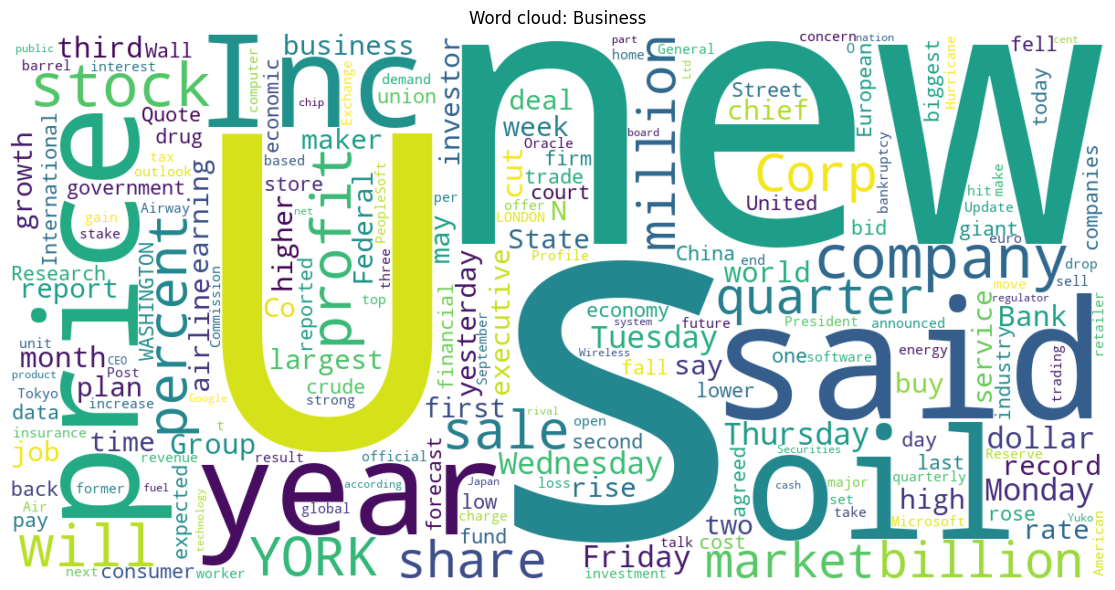

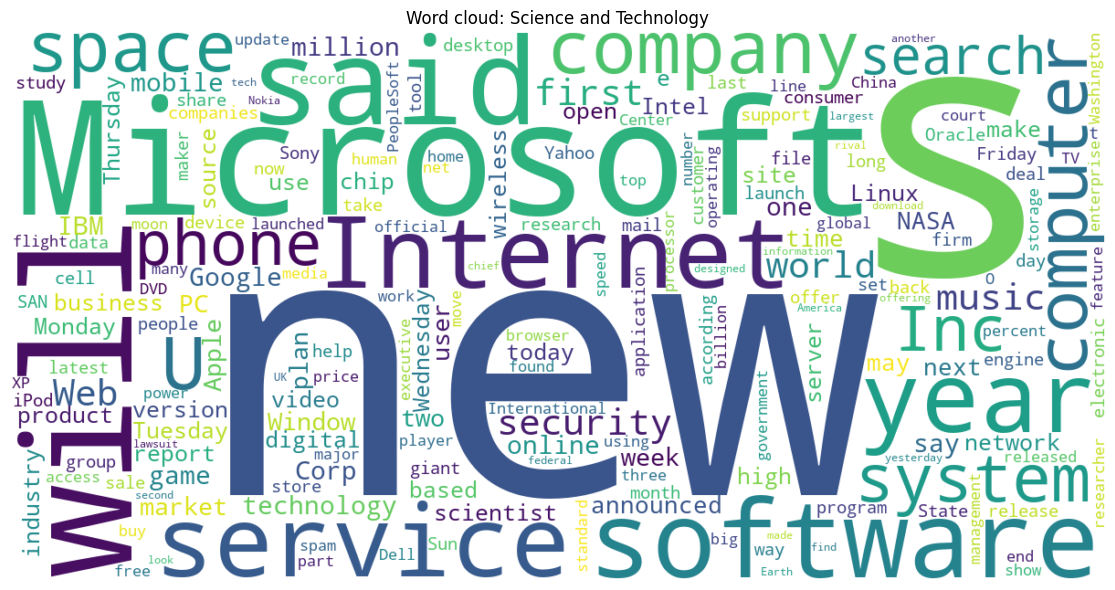

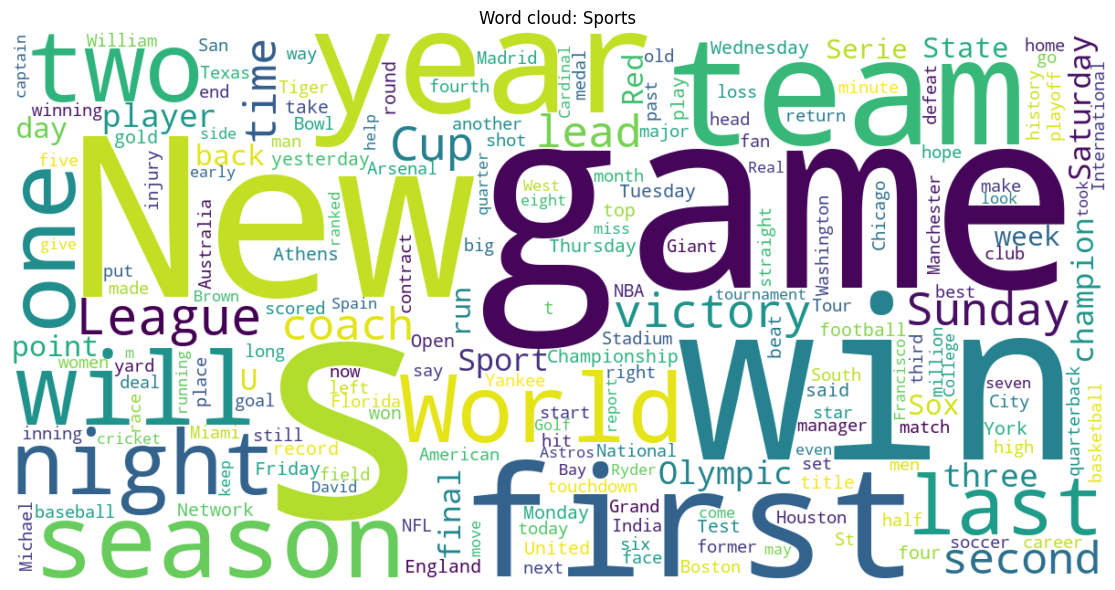

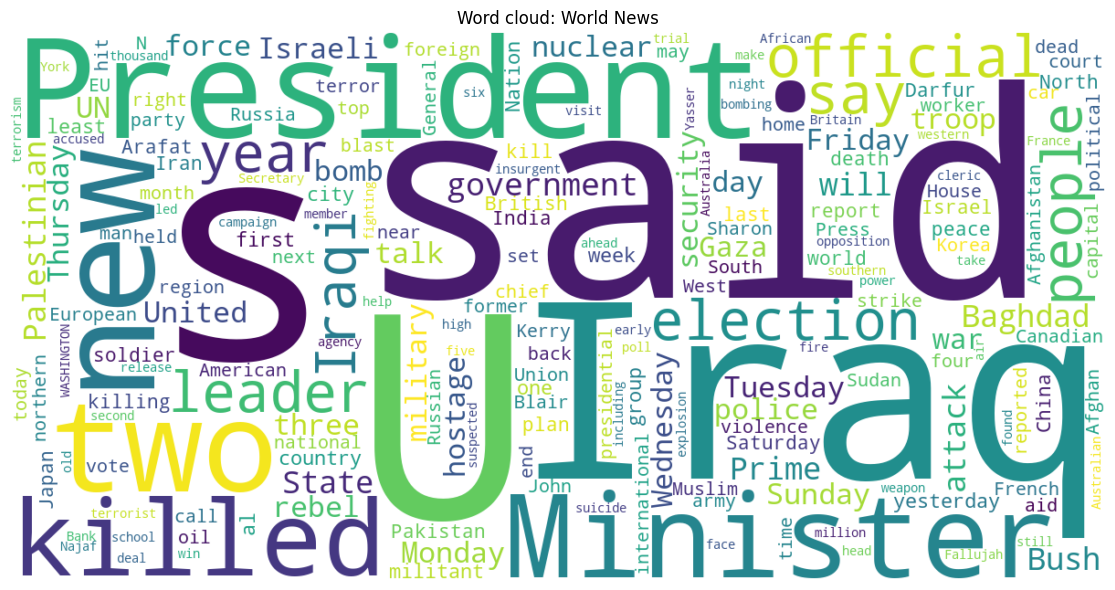

In [17]:
topic_list = sorted(train_df["News Topic"].unique())

for topic in topic_list:
    text_blob = " ".join(train_df.loc[train_df["News Topic"] == topic, "text_no_source"])
    cloud = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(text_blob)

    plt.figure(figsize=(12, 6))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word cloud: {topic}")
    plt.tight_layout()
    plt.show()

## EDA findings already visible from the dataset

1. The dataset has **104,763 training rows** and **12,000 test rows**, with **4 classes** and **no missing text or label values**.
2. The **training set is imbalanced**:
   - Science and Technology: **34.77%**
   - Sports: **32.62%**
   - Business: **17.72%**
   - World News: **14.89%**
   The **test set is perfectly balanced at 25% per class**, so macro F1 and stratified validation matter a lot.
3. Every row contains **HTML wrappers and the constant prefix `News Headlines:`**. That means HTML stripping is not optional for the preprocessed versions.
4. About **32.16%** of training rows contain broken HTML-style entities such as `#39;`, `quot;`, `amp;`, or `#151;`.
5. About **10.48%** of training rows contain backslash artifacts like `\said` or `\to`.
6. The texts are **not just short headlines**. After basic cleanup, the training texts average about **38.38 words** and **229.42 characters**, which means they behave more like **headline + short news snippet**.
7. The training set has **31,208 exact duplicate rows**, while the test set has **0**. Duplicates are concentrated almost entirely in:
   - Science and Technology: **74.15%** of rows are part of duplicate groups
   - Sports: **71.81%**
   Business and World News have effectively **0% exact duplicate rows**.
8. Digits are common in the text, especially for Sports and Business. Removing numbers in the optimum pipeline is probably a bad idea.
9. Source-wire tags are common and differ by class:
   - Business has strong Reuters presence (**18.90%**)
   - Sports has stronger AP presence (**10.35%**)
   - World News uses a mixture of Reuters, AP, and AFP
   This means source markers may create **publisher-style bias**, so removing them is a good candidate for the optimum preprocessing pipeline.
10. Exact raw train/test overlap is **0**, and overlap after basic cleanup is still very small (**15 texts**), so leakage does not look like the main issue.

## Recommended optimum preprocessing from this EDA

For this dataset, the optimum version should usually:
- remove HTML tags and the `News Headlines:` boilerplate
- normalize broken entities and backslash artifacts
- lowercase the text
- normalize whitespace
- remove source tags like Reuters/AP/AFP
- keep numbers
- keep most stopwords
- avoid stemming

The extreme version can still remove stopwords and apply stemming because the project explicitly asks for it, but the EDA suggests that **extreme preprocessing will probably lose useful meaning** for this dataset.

## Preprocessing design

We will create exactly three text versions:

1. No preprocessing
   - uses the raw text exactly as provided

2. Extreme preprocessing
   - HTML removal
   - broken entity normalization
   - source-tag removal
   - lowercasing
   - non-letter removal
   - stopword removal
   - stemming

3. Optimum preprocessing
   - HTML removal
   - broken entity normalization
   - source-tag removal
   - lowercasing
   - whitespace normalization
   - keeps numbers
   - keeps most stopwords
   - no stemming

The optimum version follows the EDA findings.

## Build the three preprocessing variants

In [18]:
STOP_WORDS = set(ENGLISH_STOP_WORDS)
STEMMER = PorterStemmer()

def preprocess_none(text):
    return str(text)

def preprocess_extreme(text):
    text = basic_eda_clean(text)
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z'\s]", " ", text)
    tokens = re.findall(r"[a-z']+", text)
    tokens = [token for token in tokens if token not in STOP_WORDS and len(token) > 1]
    tokens = [STEMMER.stem(token) for token in tokens]
    return " ".join(tokens)

def preprocess_optimum(text):
    text = basic_eda_clean(text)
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_versions = {
    "none": train_df["News Headline"].apply(preprocess_none),
    "extreme": train_df["News Headline"].apply(preprocess_extreme),
    "optimum": train_df["News Headline"].apply(preprocess_optimum)
}

test_versions = {
    "none": test_df["News Headline"].apply(preprocess_none),
    "extreme": test_df["News Headline"].apply(preprocess_extreme),
    "optimum": test_df["News Headline"].apply(preprocess_optimum)
}

## Preview the three versions side by side

In [19]:
preview_df = pd.DataFrame({
    "raw": train_df["News Headline"].head(3),
    "no_preprocessing": train_versions["none"].head(3),
    "extreme": train_versions["extreme"].head(3),
    "optimum": train_versions["optimum"].head(3)
})
preview_df

,raw,no_preprocessing,extreme,optimum
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,huge boost darfur aid effort world food programm start airlift ton food day sudan' troubl darfur region,huge boost to darfur aid effort the world food programme is starting to airlift almost 100 more tons of food a day to sudan's troubled darfur region
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...","<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",microsoft revis anti spam standard microsoft corp monday said revis propos weed spam mail win skeptic internet engin reluct adopt technolog own domin softwar compani,microsoft revises anti-spam standard microsoft corp on monday said it had revised its proposal to weed out spam e-mail to win over skeptical internet engineers who have been reluctant to adopt technology owned by the dominant software company
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>","<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",gordon cooper st astronaut ventura calif gordon cooper origin mercuri astronaut pioneer human space explor die,gordon cooper 1 of 1st astronauts ventura calif - gordon cooper who as one of the original mercury astronauts was a pioneer in human space exploration has died


## Optional extra experiment: deduplicate the training set

In [20]:
train_df_dedup = train_df.drop_duplicates(subset=["News Headline"]).copy()
print(train_df.shape)
print(train_df_dedup.shape)

train_versions_dedup = {
    "none": train_df_dedup["News Headline"].apply(preprocess_none),
    "extreme": train_df_dedup["News Headline"].apply(preprocess_extreme),
    "optimum": train_df_dedup["News Headline"].apply(preprocess_optimum)
}

(104763, 14)
(73555, 14)


## Validation split, label encoding, and class weights

In [21]:
TARGET_COLUMN = "News Topic"
TEXT_COLUMN = "text"

label_encoder = LabelEncoder()
label_encoder.fit(train_df[TARGET_COLUMN])

def make_split(text_series, label_series, test_size=0.15):
    split_df = pd.DataFrame({TEXT_COLUMN: text_series, TARGET_COLUMN: label_series})
    X_train, X_val, y_train, y_val = train_test_split(
        split_df[TEXT_COLUMN],
        split_df[TARGET_COLUMN],
        test_size=test_size,
        random_state=SEED,
        stratify=split_df[TARGET_COLUMN]
    )
    y_train_enc = label_encoder.transform(y_train)
    y_val_enc = label_encoder.transform(y_val)

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_enc),
        y=y_train_enc
    )
    class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}
    return X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, class_weight_dict

X_train_opt, X_val_opt, y_train_opt, y_val_opt, y_train_opt_enc, y_val_opt_enc, class_weights_opt = make_split(
    train_versions["optimum"],
    train_df[TARGET_COLUMN]
)

print(X_train_opt.shape, X_val_opt.shape)
print(class_weights_opt)

(89048,) (15715,)
{0: np.float64(1.4109519584231207), 1: np.float64(0.7189639581449425), 2: np.float64(0.7663075281401673), 3: np.float64(1.6795171633345907)}


## Evaluation helpers

In [22]:
EXPERIMENT_LOG = []

def evaluate_predictions(y_true, y_pred, labels):
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).T
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }
    return metrics, report_df

def show_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def log_result(preprocessing_name, representation, model_name, split_name, metrics, params):
    EXPERIMENT_LOG.append({
        "preprocessing": preprocessing_name,
        "representation": representation,
        "model": model_name,
        "split": split_name,
        "accuracy": round(metrics["accuracy"], 4),
        "macro_f1": round(metrics["macro_f1"], 4),
        "params": params
    })

## Tuning log helper

In [23]:
TUNING_LOG = []

def log_tuning(stage, preprocessing_name, model_name, params, val_accuracy, val_macro_f1, notes=""):
    TUNING_LOG.append({
        "stage": stage,
        "preprocessing": preprocessing_name,
        "model": model_name,
        "params": str(params),
        "val_accuracy": round(val_accuracy, 4),
        "val_macro_f1": round(val_macro_f1, 4),
        "notes": notes
    })

def tuning_table():
    return pd.DataFrame(TUNING_LOG).sort_values(["stage", "val_macro_f1"], ascending=[True, False])

## TF-IDF feature helper

In [24]:
def build_tfidf_features(X_train, X_val, max_features=50000, ngram_range=(1, 2), min_df=3, max_df=0.95):
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        sublinear_tf=True
    )
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf = vectorizer.transform(X_val)
    return vectorizer, X_train_tfidf, X_val_tfidf

## TF-IDF with Logistic Regression

In [25]:
def run_logistic_regression(preprocessing_name, train_text, train_labels, class_weight="balanced", C=3.0):
    X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, _ = make_split(train_text, train_labels)
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        X_train,
        X_val,
        max_features=40000,
        ngram_range=(1, 2),
        min_df=3
    )

    model = LogisticRegression(
        C=C,
        max_iter=1500,
        class_weight=class_weight
    )
    model.fit(X_train_tfidf, y_train)
    val_pred = model.predict(X_val_tfidf)

    metrics, report_df = evaluate_predictions(y_val, val_pred, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "LogisticRegression", "validation", metrics, {"C": C, "class_weight": class_weight})
    log_tuning("TF-IDF_ML", preprocessing_name, "LogisticRegression", {"C": C, "class_weight": class_weight}, metrics["accuracy"], metrics["macro_f1"])

    print(metrics)
    display(report_df)
    show_confusion(y_val, val_pred, label_encoder.classes_, f"Logistic Regression | {preprocessing_name}")
    return model, vectorizer, metrics, report_df

## Run Logistic Regression on all three preprocessing variants

Running Logistic Regression for: none
{'accuracy': 0.9410117721921731, 'macro_f1': 0.929940353610714}


,precision,recall,f1-score,support
Business,0.895026,0.878636,0.886755,2785.000000
Science and Technology,0.943531,0.944912,0.944221,5464.000000
Sports,0.975558,0.988687,0.982079,5127.000000
World News,0.911803,0.901667,0.906707,2339.000000
accuracy,0.941012,0.941012,0.941012,0.941012
macro avg,0.931479,0.928476,0.929940,15715.000000
weighted avg,0.940661,0.941012,0.940804,15715.000000


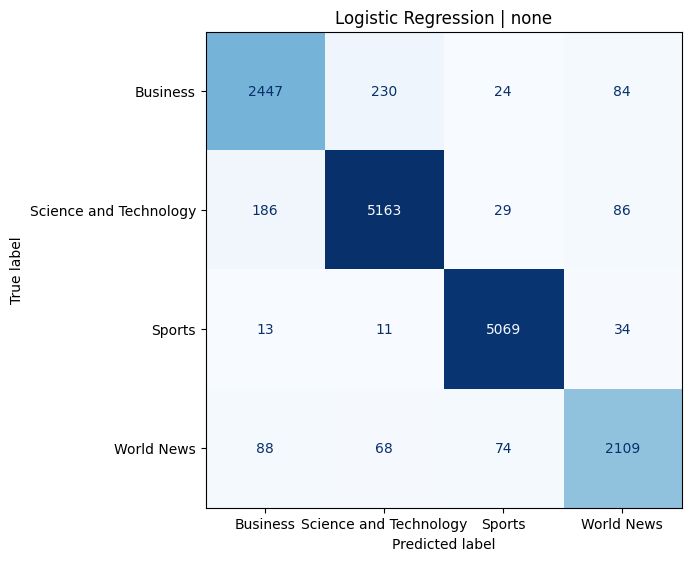

Running Logistic Regression for: extreme
{'accuracy': 0.93445752465797, 'macro_f1': 0.9224794663622709}


,precision,recall,f1-score,support
Business,0.873118,0.874686,0.873901,2785.000000
Science and Technology,0.939657,0.931918,0.935771,5464.000000
Sports,0.977040,0.987712,0.982347,5127.000000
World News,0.900990,0.894827,0.897898,2339.000000
accuracy,0.934458,0.934458,0.934458,0.934458
macro avg,0.922701,0.922286,0.922479,15715.000000
weighted avg,0.934306,0.934458,0.934365,15715.000000


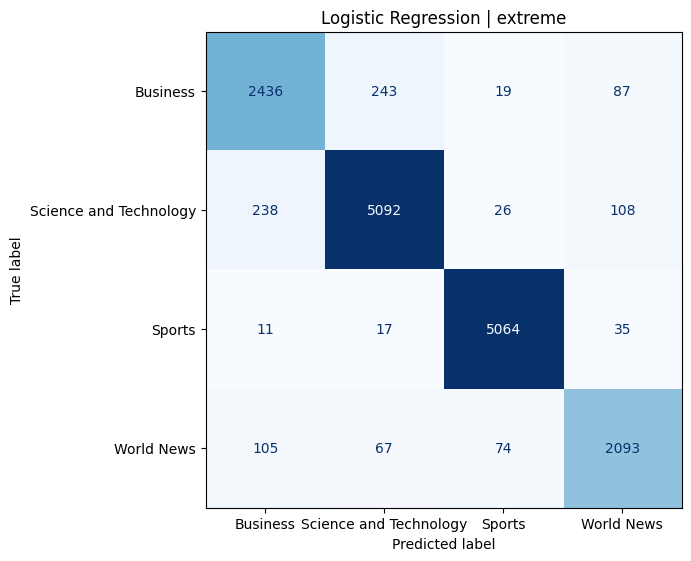

Running Logistic Regression for: optimum
{'accuracy': 0.9375755647470569, 'macro_f1': 0.9258478986928745}


,precision,recall,f1-score,support
Business,0.880462,0.875404,0.877926,2785.000000
Science and Technology,0.939799,0.939971,0.939885,5464.000000
Sports,0.975221,0.990248,0.982677,5127.000000
World News,0.915604,0.890552,0.902904,2339.000000
accuracy,0.937576,0.937576,0.937576,0.937576
macro avg,0.927772,0.924043,0.925848,15715.000000
weighted avg,0.937239,0.937576,0.937361,15715.000000


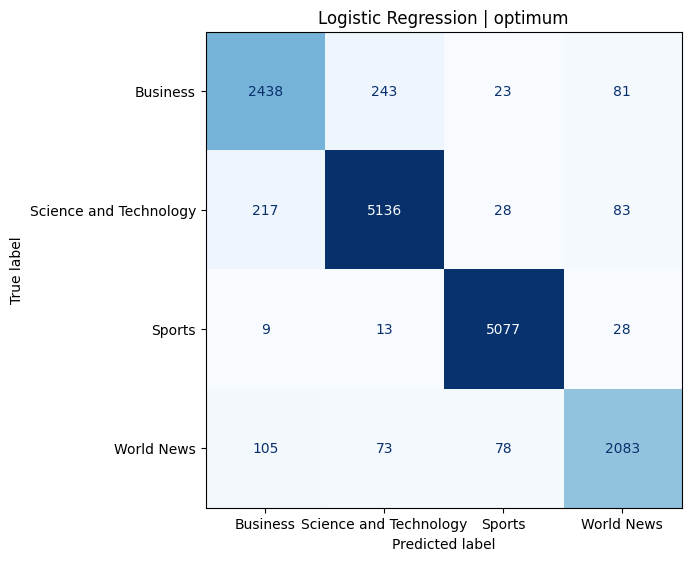

In [26]:
logreg_runs = {}

for preprocessing_name in ["none", "extreme", "optimum"]:
    print("=" * 80)
    print(f"Running Logistic Regression for: {preprocessing_name}")
    logreg_runs[preprocessing_name] = run_logistic_regression(
        preprocessing_name,
        train_versions[preprocessing_name],
        train_df["News Topic"],
        class_weight="balanced",
        C=3.0
    )

## Optional TF-IDF baselines: MultinomialNB and RandomForest

In [27]:
def run_multinomial_nb(preprocessing_name, train_text, train_labels, alpha=0.5):
    X_train, X_val, y_train, y_val, _, _, _ = make_split(train_text, train_labels)
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        X_train,
        X_val,
        max_features=40000,
        ngram_range=(1, 2),
        min_df=3
    )

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tfidf, y_train)
    val_pred = model.predict(X_val_tfidf)

    metrics, report_df = evaluate_predictions(y_val, val_pred, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "MultinomialNB", "validation", metrics, {"alpha": alpha})
    log_tuning("TF-IDF_ML", preprocessing_name, "MultinomialNB", {"alpha": alpha}, metrics["accuracy"], metrics["macro_f1"])
    return model, vectorizer, metrics, report_df

def run_random_forest(preprocessing_name, train_text, train_labels, n_estimators=300, max_depth=None):
    X_train, X_val, y_train, y_val, _, _, _ = make_split(train_text, train_labels)
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        X_train,
        X_val,
        max_features=20000,
        ngram_range=(1, 2),
        min_df=3
    )

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train_tfidf, y_train)
    val_pred = model.predict(X_val_tfidf)

    metrics, report_df = evaluate_predictions(y_val, val_pred, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "RandomForest", "validation", metrics, {"n_estimators": n_estimators, "max_depth": max_depth})
    log_tuning("TF-IDF_ML", preprocessing_name, "RandomForest", {"n_estimators": n_estimators, "max_depth": max_depth}, metrics["accuracy"], metrics["macro_f1"])
    return model, vectorizer, metrics, report_df

## TF-IDF + Deep Neural Network

The PDF asks for a DNN with at least 3 to 4+ layers and 128+ neurons in the first layer.

Because raw TF-IDF can be very high-dimensional, two practical options are:

1. use sparse TF-IDF directly as Keras input
2. reduce TF-IDF with TruncatedSVD first, then train the DNN on dense vectors

The cells below implement the safer dense version using TruncatedSVD. It still starts from TF-IDF.

## DNN builder and training function

In [28]:
def build_tfidf_dnn(input_dim, n_classes, learning_rate=1e-3, dropout_rate=0.3):
    model = Sequential([
        Dense(512, activation="relu", input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(256, activation="relu"),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_tfidf_dnn(preprocessing_name, train_text, train_labels, n_components=1024, batch_size=256, epochs=15):
    X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, class_weight_dict = make_split(train_text, train_labels)
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        X_train,
        X_val,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=3
    )

    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    X_train_dense = svd.fit_transform(X_train_tfidf).astype("float32")
    X_val_dense = svd.transform(X_val_tfidf).astype("float32")

    model = build_tfidf_dnn(X_train_dense.shape[1], len(label_encoder.classes_))

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
    ]

    history = model.fit(
        X_train_dense,
        y_train_enc,
        validation_data=(X_val_dense, y_val_enc),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    val_pred = model.predict(X_val_dense, verbose=0).argmax(axis=1)
    val_pred_labels = label_encoder.inverse_transform(val_pred)

    metrics, report_df = evaluate_predictions(y_val, val_pred_labels, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "DeepNN", "validation", metrics, {"n_components": n_components, "batch_size": batch_size, "epochs": epochs})
    log_tuning("TF-IDF_DNN", preprocessing_name, "DeepNN", {"n_components": n_components, "batch_size": batch_size, "epochs": epochs}, metrics["accuracy"], metrics["macro_f1"])

    print(metrics)
    display(report_df)
    show_confusion(y_val, val_pred_labels, label_encoder.classes_, f"DNN | {preprocessing_name}")
    return model, vectorizer, svd, history, metrics, report_df

## Run the TF-IDF DNN on all three preprocessing variants

Running DNN for: none
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8506 - loss: 0.4505 - val_accuracy: 0.9148 - val_loss: 0.2556 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9206 - loss: 0.2672 - val_accuracy: 0.9206 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9385 - loss: 0.2117 - val_accuracy: 0.9320 - val_loss: 0.2083 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9540 - loss: 0.1603 - val_accuracy: 0.9370 - val_loss: 0.2006 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9655 - loss: 0.1180 - val_accuracy: 0.9419 - val_loss: 0.2005 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9730 - loss: 0.0884 - val_accuracy: 0.9425 - val_loss: 0.2154 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accur

,precision,recall,f1-score,support
Business,0.906180,0.873968,0.889782,2785.000000
Science and Technology,0.942249,0.955527,0.948841,5464.000000
Sports,0.979341,0.980105,0.979723,5127.000000
World News,0.900297,0.907225,0.903748,2339.000000
accuracy,0.941903,0.941903,0.941903,0.941903
macro avg,0.932017,0.929206,0.930524,15715.000000
weighted avg,0.941714,0.941903,0.941739,15715.000000


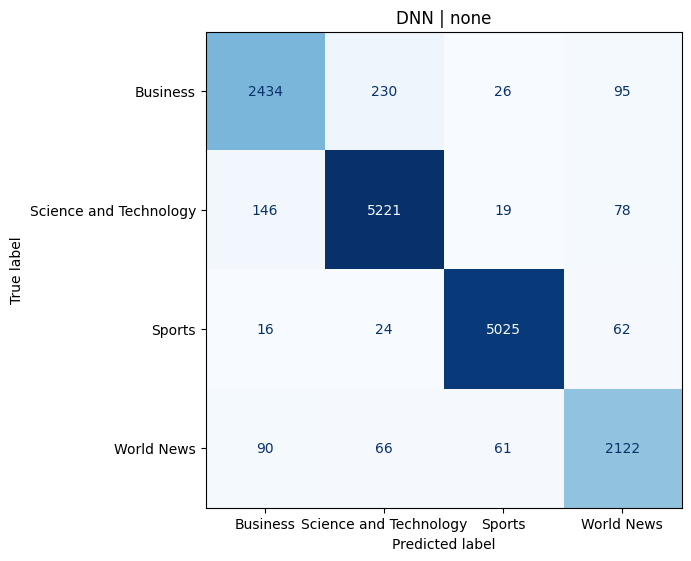

Running DNN for: extreme
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8454 - loss: 0.4582 - val_accuracy: 0.9087 - val_loss: 0.2742 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9199 - loss: 0.2757 - val_accuracy: 0.9211 - val_loss: 0.2413 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9368 - loss: 0.2235 - val_accuracy: 0.9294 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9498 - loss: 0.1763 - val_accuracy: 0.9317 - val_loss: 0.2176 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9605 - loss: 0.1364 - val_accuracy: 0.9337 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9689 - loss: 0.1023 - val_accuracy: 0.9349 - val_loss: 0.2490 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - ac

,precision,recall,f1-score,support
Business,0.866619,0.863196,0.864904,2785.000000
Science and Technology,0.934576,0.935944,0.935260,5464.000000
Sports,0.970004,0.990248,0.980021,5127.000000
World News,0.915884,0.875160,0.895059,2339.000000
accuracy,0.931721,0.931721,0.931721,0.931721
macro avg,0.921771,0.916137,0.918811,15715.000000
weighted avg,0.931309,0.931721,0.931411,15715.000000


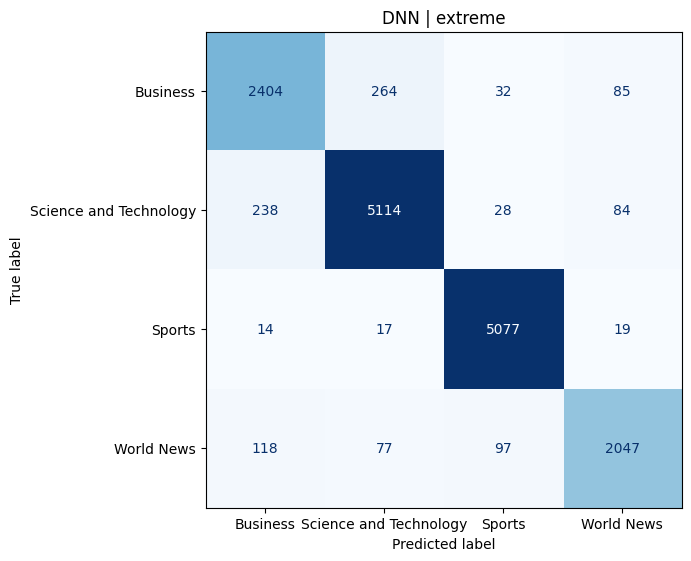

Running DNN for: optimum
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8462 - loss: 0.4727 - val_accuracy: 0.9056 - val_loss: 0.2765 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9163 - loss: 0.2832 - val_accuracy: 0.9185 - val_loss: 0.2436 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9334 - loss: 0.2267 - val_accuracy: 0.9226 - val_loss: 0.2290 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9496 - loss: 0.1768 - val_accuracy: 0.9265 - val_loss: 0.2275 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9603 - loss: 0.1342 - val_accuracy: 0.9357 - val_loss: 0.2226 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9685 - loss: 0.1030 - val_accuracy: 0.9369 - val_loss: 0.2335 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - ac

,precision,recall,f1-score,support
Business,0.879636,0.868582,0.874074,2785.00000
Science and Technology,0.934488,0.947657,0.941027,5464.00000
Sports,0.978864,0.984591,0.981719,5127.00000
World News,0.908690,0.880718,0.894485,2339.00000
accuracy,0.935730,0.935730,0.935730,0.93573
macro avg,0.925420,0.920387,0.922826,15715.00000
weighted avg,0.935405,0.935730,0.935510,15715.00000


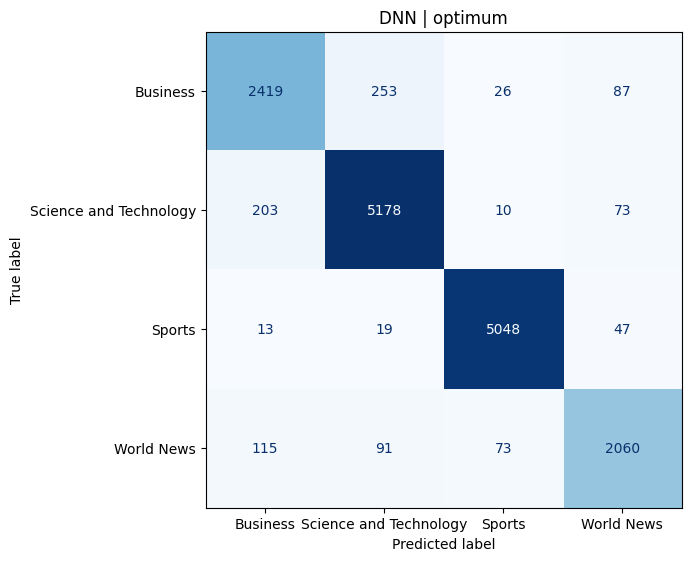

In [29]:
dnn_runs = {}

for preprocessing_name in ["none", "extreme", "optimum"]:
    print("=" * 80)
    print(f"Running DNN for: {preprocessing_name}")
    dnn_runs[preprocessing_name] = run_tfidf_dnn(
        preprocessing_name,
        train_versions[preprocessing_name],
        train_df["News Topic"],
        n_components=1024,
        batch_size=256,
        epochs=12
    )

## Skip-gram preparation

The recurrent models in the PDF should use Skip-gram embeddings.

The workflow below is:
1. tokenize the chosen preprocessed text
2. train Word2Vec with `sg=1`
3. build a tokenizer and padded sequences
4. create the embedding matrix
5. train RNN / GRU / LSTM / bidirectional variants

## Skip-gram helpers

In [30]:
def tokenize_for_skipgram(text_series):
    return [text.split() for text in text_series]

def train_skipgram_embeddings(tokenized_texts, vector_size=200, window=5, min_count=2, epochs=15):
    model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,
        workers=4,
        epochs=epochs,
        seed=SEED
    )
    return model

def build_sequence_data(train_text, val_text, max_vocab=50000, max_len=60):
    tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_text)

    X_train_seq = tokenizer.texts_to_sequences(train_text)
    X_val_seq = tokenizer.texts_to_sequences(val_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
    return tokenizer, X_train_pad, X_val_pad

def build_embedding_matrix(tokenizer, w2v_model, max_vocab=50000):
    embedding_dim = w2v_model.vector_size
    vocab_size = min(max_vocab, len(tokenizer.word_index) + 1)

    embedding_matrix = np.random.normal(0, 0.05, (vocab_size, embedding_dim))
    embedding_matrix[0] = np.zeros(embedding_dim)

    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]

    return embedding_matrix

## Prepare tokenizer, sequences, and embedding matrix

In [31]:
def prepare_skipgram_inputs(preprocessing_name, train_text_series, train_labels, max_vocab=50000, max_len=60):
    X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, class_weight_dict = make_split(train_text_series, train_labels)

    tokenized_train = tokenize_for_skipgram(X_train)
    w2v_model = train_skipgram_embeddings(
        tokenized_train,
        vector_size=200,
        window=5,
        min_count=2,
        epochs=15
    )

    tokenizer, X_train_pad, X_val_pad = build_sequence_data(X_train, X_val, max_vocab=max_vocab, max_len=max_len)
    embedding_matrix = build_embedding_matrix(tokenizer, w2v_model, max_vocab=max_vocab)

    return {
        "preprocessing": preprocessing_name,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "y_train_enc": y_train_enc,
        "y_val_enc": y_val_enc,
        "class_weights": class_weight_dict,
        "tokenizer": tokenizer,
        "X_train_pad": X_train_pad,
        "X_val_pad": X_val_pad,
        "embedding_matrix": embedding_matrix,
        "max_vocab": max_vocab,
        "max_len": max_len
    }

## Recurrent model builders

In [32]:
def build_simple_rnn_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        SimpleRNN(units),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_gru_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        GRU(units),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_lstm_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        LSTM(units),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_bi_simple_rnn_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        Bidirectional(SimpleRNN(units)),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_bi_gru_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        Bidirectional(GRU(units)),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_bi_lstm_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        Bidirectional(LSTM(units)),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

## Unified training helper for sequence models

In [33]:
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_sequence_model(prepared_data, model_name, units=128, dropout_rate=0.3, batch_size=256, epochs=12):
    embedding_matrix = prepared_data["embedding_matrix"]
    vocab_size = embedding_matrix.shape[0]
    max_len = prepared_data["max_len"]
    n_classes = len(label_encoder.classes_)

    builders = {
        "SimpleRNN": build_simple_rnn_model,
        "GRU": build_gru_model,
        "LSTM": build_lstm_model,
        "BiSimpleRNN": build_bi_simple_rnn_model,
        "BiGRU": build_bi_gru_model,
        "BiLSTM": build_bi_lstm_model
    }

    model = builders[model_name](
        vocab_size=vocab_size,
        embedding_matrix=embedding_matrix,
        max_len=max_len,
        n_classes=n_classes,
        units=units,
        dropout_rate=dropout_rate
    )
    model = compile_model(model)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
    ]

    history = model.fit(
        prepared_data["X_train_pad"],
        prepared_data["y_train_enc"],
        validation_data=(prepared_data["X_val_pad"], prepared_data["y_val_enc"]),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=prepared_data["class_weights"],
        callbacks=callbacks,
        verbose=1
    )

    val_pred = model.predict(prepared_data["X_val_pad"], verbose=0).argmax(axis=1)
    val_pred_labels = label_encoder.inverse_transform(val_pred)
    y_val_labels = prepared_data["y_val"]

    metrics, report_df = evaluate_predictions(y_val_labels, val_pred_labels, label_encoder.classes_)
    log_result(prepared_data["preprocessing"], "Skip-gram", model_name, "validation", metrics, {"units": units, "dropout_rate": dropout_rate, "batch_size": batch_size, "epochs": epochs})
    log_tuning("SKIPGRAM_RNN", prepared_data["preprocessing"], model_name, {"units": units, "dropout_rate": dropout_rate, "batch_size": batch_size, "epochs": epochs}, metrics["accuracy"], metrics["macro_f1"])

    print(metrics)
    display(report_df)
    show_confusion(y_val_labels, val_pred_labels, label_encoder.classes_, f"{model_name} | {prepared_data['preprocessing']}")
    return model, history, metrics, report_df

## Prepare one Skip-gram dataset first

In [34]:
prepared_optimum = prepare_skipgram_inputs(
    "optimum",
    train_versions["optimum"],
    train_df["News Topic"],
    max_vocab=50000,
    max_len=60
)

prepared_optimum.keys()

dict_keys(['preprocessing', 'X_train', 'X_val', 'y_train', 'y_val', 'y_train_enc', 'y_val_enc', 'class_weights', 'tokenizer', 'X_train_pad', 'X_val_pad', 'embedding_matrix', 'max_vocab', 'max_len'])

## Run the six required sequence models on the optimum preprocessing first

Running SimpleRNN on optimum preprocessing
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.4702 - loss: 1.1359 - val_accuracy: 0.4733 - val_loss: 0.9303 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.5405 - loss: 0.9934 - val_accuracy: 0.5690 - val_loss: 0.7391 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.5093 - loss: 1.1221 - val_accuracy: 0.5436 - val_loss: 0.9746 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.5935 - loss: 0.9630 - val_accuracy: 0.4772 - val_loss: 0.9994 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.6664 - loss: 0.7900 - val_accuracy: 0.7194 - val_loss: 0.6490 - learning_rate: 5.0000e-04
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7154 - loss: 0.7224 - val_accuracy: 0.7858 - val_loss: 0.5446 - learning_rate: 5.0000e-04
Epoch 7/12
348/348 ━━━━━━

,precision,recall,f1-score,support
Business,0.680851,0.850269,0.756187,2785.000000
Science and Technology,0.929866,0.788616,0.853436,5464.000000
Sports,0.946998,0.972303,0.959484,5127.000000
World News,0.845233,0.845233,0.845233,2339.000000
accuracy,0.867897,0.867897,0.867897,0.867897
macro avg,0.850737,0.864106,0.853585,15715.000000
weighted avg,0.878729,0.867897,0.869579,15715.000000


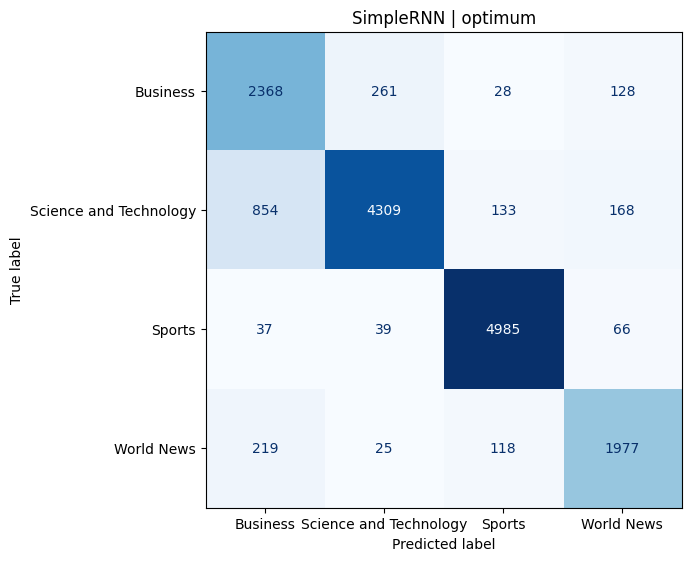

Running GRU on optimum preprocessing
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 47s 130ms/step - accuracy: 0.7005 - loss: 0.7054 - val_accuracy: 0.8959 - val_loss: 0.3140 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.8941 - loss: 0.3500 - val_accuracy: 0.9084 - val_loss: 0.2688 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 44s 127ms/step - accuracy: 0.9022 - loss: 0.3199 - val_accuracy: 0.9134 - val_loss: 0.2515 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.9085 - loss: 0.2982 - val_accuracy: 0.9185 - val_loss: 0.2389 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.9126 - loss: 0.2873 - val_accuracy: 0.9206 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.9165 - loss: 0.2720 - val_accuracy: 0.9174 - val_loss: 0.2387 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━━━━

,precision,recall,f1-score,support
Business,0.828032,0.897307,0.861279,2785.000000
Science and Technology,0.945229,0.906479,0.925448,5464.000000
Sports,0.976392,0.992198,0.984231,5127.000000
World News,0.917223,0.881146,0.898823,2339.000000
accuracy,0.929049,0.929049,0.929049,0.929049
macro avg,0.916719,0.919282,0.917445,15715.000000
weighted avg,0.930458,0.929049,0.929291,15715.000000


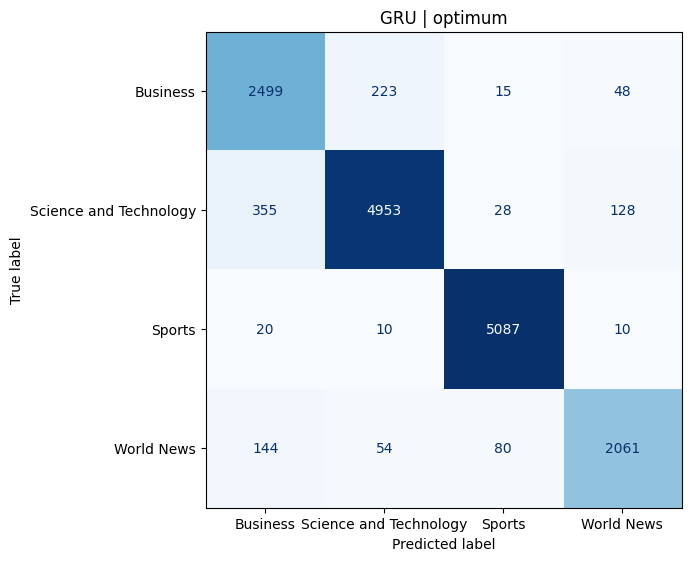

Running LSTM on optimum preprocessing
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 53s 146ms/step - accuracy: 0.8318 - loss: 0.5266 - val_accuracy: 0.9082 - val_loss: 0.3010 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 52s 150ms/step - accuracy: 0.8829 - loss: 0.3829 - val_accuracy: 0.9114 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 85s 157ms/step - accuracy: 0.8948 - loss: 0.3449 - val_accuracy: 0.9178 - val_loss: 0.2584 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.9021 - loss: 0.3210 - val_accuracy: 0.9138 - val_loss: 0.2534 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.9066 - loss: 0.3044 - val_accuracy: 0.9121 - val_loss: 0.2581 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.9119 - loss: 0.2921 - val_accuracy: 0.9140 - val_loss: 0.2439 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━━━

,precision,recall,f1-score,support
Business,0.815858,0.905206,0.858213,2785.000000
Science and Technology,0.949458,0.897328,0.922657,5464.000000
Sports,0.979868,0.987322,0.983581,5127.000000
World News,0.911547,0.894399,0.902892,2339.000000
accuracy,0.927649,0.927649,0.927649,0.927649
macro avg,0.914183,0.921064,0.916836,15715.000000
weighted avg,0.930060,0.927649,0.928171,15715.000000


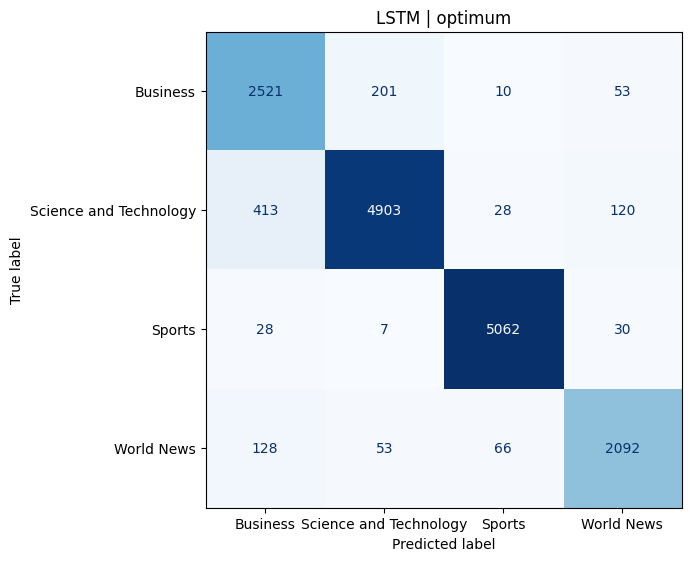

Running BiSimpleRNN on optimum preprocessing
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8192 - loss: 0.5392 - val_accuracy: 0.8946 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.8629 - loss: 0.4384 - val_accuracy: 0.8881 - val_loss: 0.3344 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8633 - loss: 0.4353 - val_accuracy: 0.8978 - val_loss: 0.3145 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8717 - loss: 0.4106 - val_accuracy: 0.8923 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.8716 - loss: 0.4115 - val_accuracy: 0.8639 - val_loss: 0.3784 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.8775 - loss: 0.3951 - val_accuracy: 0.9017 - val_loss: 0.2951 - learning_rate: 5.0000e-04
Epoch 7/12
348/348 ━━━━━━━━

,precision,recall,f1-score,support
Business,0.753392,0.897307,0.819076,2785.000000
Science and Technology,0.944286,0.849927,0.894625,5464.000000
Sports,0.965339,0.983226,0.974200,5127.000000
World News,0.894154,0.863189,0.878399,2339.000000
accuracy,0.903786,0.903786,0.903786,0.903786
macro avg,0.889293,0.898412,0.891575,15715.000000
weighted avg,0.909863,0.903786,0.904783,15715.000000


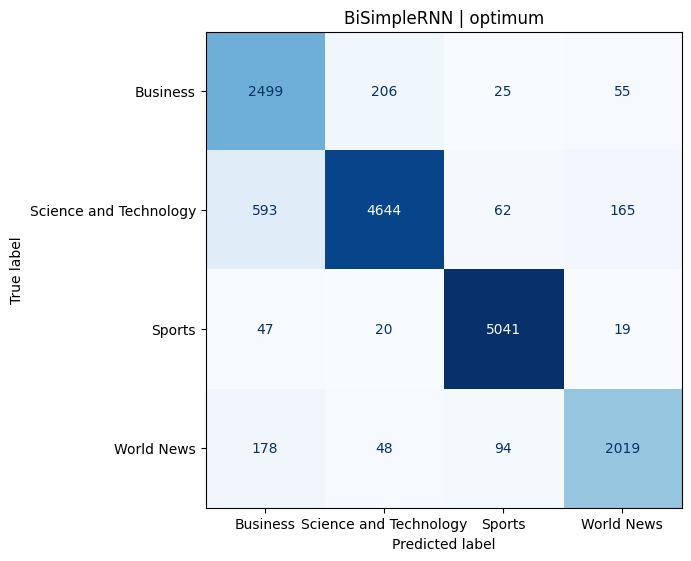

Running BiGRU on optimum preprocessing
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 49s 132ms/step - accuracy: 0.8519 - loss: 0.4459 - val_accuracy: 0.9030 - val_loss: 0.2793 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.8971 - loss: 0.3319 - val_accuracy: 0.9103 - val_loss: 0.2612 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - accuracy: 0.9043 - loss: 0.3086 - val_accuracy: 0.9134 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - accuracy: 0.9094 - loss: 0.2922 - val_accuracy: 0.9121 - val_loss: 0.2469 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9133 - loss: 0.2816 - val_accuracy: 0.9180 - val_loss: 0.2344 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9178 - loss: 0.2687 - val_accuracy: 0.9231 - val_loss: 0.2221 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━━

,precision,recall,f1-score,support
Business,0.813587,0.907361,0.857919,2785.000000
Science and Technology,0.950912,0.896962,0.923149,5464.000000
Sports,0.980290,0.989468,0.984857,5127.000000
World News,0.911842,0.888841,0.900195,2339.000000
accuracy,0.927776,0.927776,0.927776,0.927776
macro avg,0.914158,0.920658,0.916530,15715.000000
weighted avg,0.930345,0.927776,0.928305,15715.000000


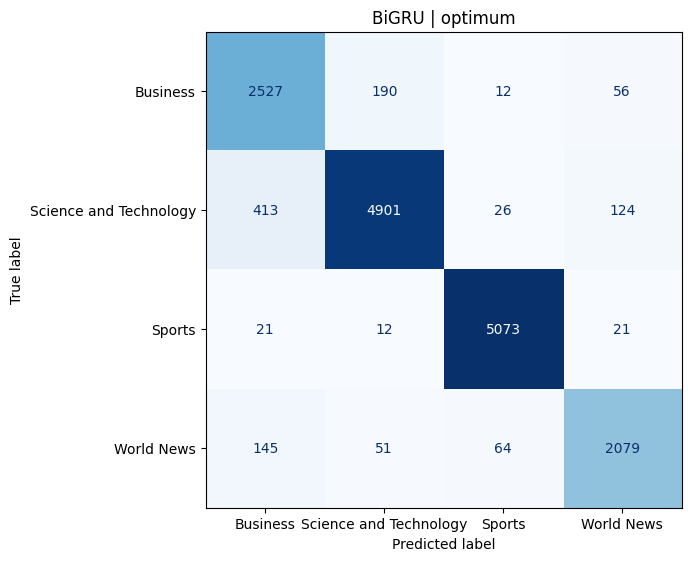

Running BiLSTM on optimum preprocessing
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 62s 171ms/step - accuracy: 0.8593 - loss: 0.4346 - val_accuracy: 0.9066 - val_loss: 0.2680 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 173ms/step - accuracy: 0.8930 - loss: 0.3386 - val_accuracy: 0.8971 - val_loss: 0.2804 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.9028 - loss: 0.3106 - val_accuracy: 0.9054 - val_loss: 0.2631 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 59s 170ms/step - accuracy: 0.9107 - loss: 0.2897 - val_accuracy: 0.9156 - val_loss: 0.2410 - learning_rate: 0.0010
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 61s 175ms/step - accuracy: 0.9135 - loss: 0.2776 - val_accuracy: 0.9121 - val_loss: 0.2479 - learning_rate: 0.0010
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.9187 - loss: 0.2653 - val_accuracy: 0.9139 - val_loss: 0.2399 - learning_rate: 0.0010
Epoch 7/12
348/348 ━━━━━━━━━━━

,precision,recall,f1-score,support
Business,0.806686,0.918492,0.858966,2785.000000
Science and Technology,0.956334,0.893851,0.924037,5464.000000
Sports,0.979395,0.992003,0.985659,5127.000000
World News,0.920232,0.882856,0.901156,2339.000000
accuracy,0.928603,0.928603,0.928603,0.928603
macro avg,0.915662,0.921800,0.917455,15715.000000
weighted avg,0.931964,0.928603,0.929204,15715.000000


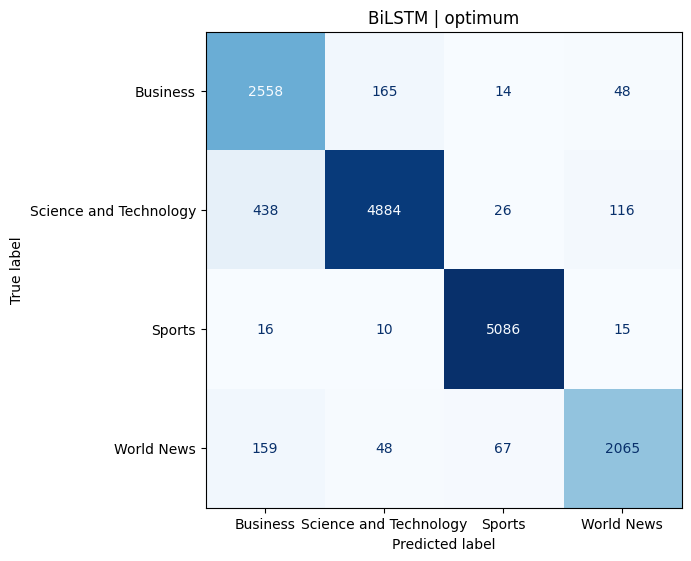

In [35]:
sequence_runs_optimum = {}

for model_name in ["SimpleRNN", "GRU", "LSTM", "BiSimpleRNN", "BiGRU", "BiLSTM"]:
    print("=" * 80)
    print(f"Running {model_name} on optimum preprocessing")
    sequence_runs_optimum[model_name] = run_sequence_model(
        prepared_optimum,
        model_name=model_name,
        units=128,
        dropout_rate=0.3,
        batch_size=256,
        epochs=12
    )

## Full long-running cell: run the six sequence models on all three preprocessing variants

Running SimpleRNN on none
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 83s 225ms/step - accuracy: 0.6351 - loss: 0.9099 - val_accuracy: 0.7801 - val_loss: 0.6283 - learning_rate: 0.0010
Epoch 2/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 79s 226ms/step - accuracy: 0.5514 - loss: 1.0618 - val_accuracy: 0.4697 - val_loss: 0.9288 - learning_rate: 0.0010
Epoch 3/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 77s 222ms/step - accuracy: 0.5442 - loss: 0.9626 - val_accuracy: 0.6961 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 4/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 80s 230ms/step - accuracy: 0.6953 - loss: 0.7177 - val_accuracy: 0.8052 - val_loss: 0.5363 - learning_rate: 5.0000e-04
Epoch 5/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 78s 224ms/step - accuracy: 0.7818 - loss: 0.6258 - val_accuracy: 0.8470 - val_loss: 0.4521 - learning_rate: 5.0000e-04
Epoch 6/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 80s 230ms/step - accuracy: 0.8034 - loss: 0.5881 - val_accuracy: 0.8391 - val_loss: 0.4679 - learning_rate: 5.0000e-04
Epoch 7/12
348/348 ━━━━━━━━━━━━━

,precision,recall,f1-score,support
Business,0.735178,0.801436,0.766879,2785.000000
Science and Technology,0.900923,0.803807,0.849599,5464.000000
Sports,0.920362,0.951239,0.935546,5127.000000
World News,0.781637,0.837110,0.808423,2339.000000
accuracy,0.856443,0.856443,0.856443,0.856443
macro avg,0.834525,0.848398,0.840111,15715.000000
weighted avg,0.860137,0.856443,0.856851,15715.000000


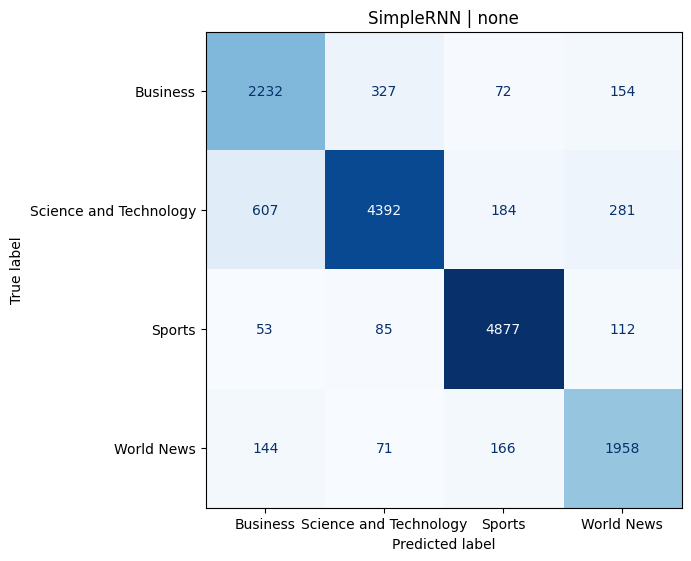

Running GRU on none
Epoch 1/12
348/348 ━━━━━━━━━━━━━━━━━━━━ 196s 471ms/step - accuracy: 0.6981 - loss: 0.7092 - val_accuracy: 0.8857 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 2/12
216/348 ━━━━━━━━━━━━━━━━━━━━ 34s 263ms/step - accuracy: 0.8615 - loss: 0.4410

KeyboardInterrupt: 

In [36]:
sequence_runs_all = {}

for preprocessing_name in ["none", "extreme", "optimum"]:
    prepared_data = prepare_skipgram_inputs(
        preprocessing_name,
        train_versions[preprocessing_name],
        train_df["News Topic"],
        max_vocab=50000,
        max_len=60
    )

    for model_name in ["SimpleRNN", "GRU", "LSTM", "BiSimpleRNN", "BiGRU", "BiLSTM"]:
        print("=" * 80)
        print(f"Running {model_name} on {preprocessing_name}")
        sequence_runs_all[(preprocessing_name, model_name)] = run_sequence_model(
            prepared_data,
            model_name=model_name,
            units=128,
            dropout_rate=0.3,
            batch_size=256,
            epochs=12
        )

## Experiment results table

In [37]:
results_df = pd.DataFrame(EXPERIMENT_LOG)
results_df.sort_values(["representation", "macro_f1"], ascending=[True, False])

,preprocessing,representation,model,split,accuracy,macro_f1,params
11,optimum,Skip-gram,BiLSTM,validation,0.9286,0.9175,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
7,optimum,Skip-gram,GRU,validation,0.9290,0.9174,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
8,optimum,Skip-gram,LSTM,validation,0.9276,0.9168,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
10,optimum,Skip-gram,BiGRU,validation,0.9278,0.9165,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
9,optimum,Skip-gram,BiSimpleRNN,validation,0.9038,0.8916,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
6,optimum,Skip-gram,SimpleRNN,validation,0.8679,0.8536,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
12,none,Skip-gram,SimpleRNN,validation,0.8564,0.8401,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
3,none,TF-IDF,DeepNN,validation,0.9419,0.9305,"{'n_components': 1024, 'batch_size': 256, 'epochs': 12}"
0,none,TF-IDF,LogisticRegression,validation,0.9410,0.9299,"{'C': 3.0, 'class_weight': 'balanced'}"
2,optimum,TF-IDF,LogisticRegression,validation,0.9376,0.9258,"{'C': 3.0, 'class_weight': 'balanced'}"


## Experiment comparison plot

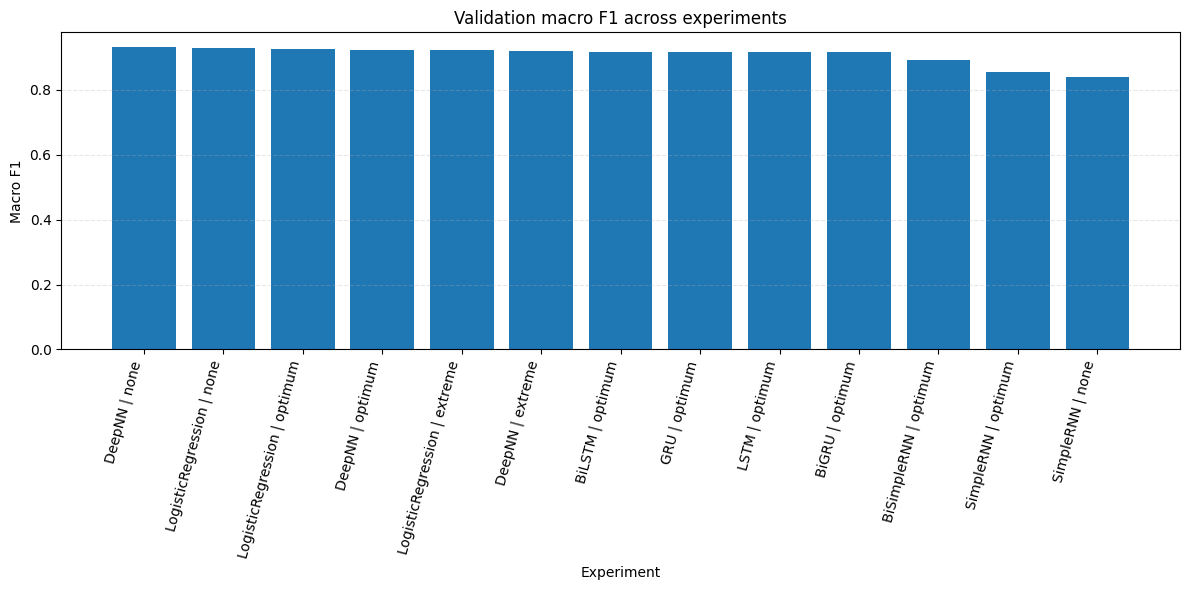

,preprocessing,representation,model,split,accuracy,macro_f1,params
3,none,TF-IDF,DeepNN,validation,0.9419,0.9305,"{'n_components': 1024, 'batch_size': 256, 'epochs': 12}"
0,none,TF-IDF,LogisticRegression,validation,0.9410,0.9299,"{'C': 3.0, 'class_weight': 'balanced'}"
2,optimum,TF-IDF,LogisticRegression,validation,0.9376,0.9258,"{'C': 3.0, 'class_weight': 'balanced'}"
5,optimum,TF-IDF,DeepNN,validation,0.9357,0.9228,"{'n_components': 1024, 'batch_size': 256, 'epochs': 12}"
1,extreme,TF-IDF,LogisticRegression,validation,0.9345,0.9225,"{'C': 3.0, 'class_weight': 'balanced'}"
4,extreme,TF-IDF,DeepNN,validation,0.9317,0.9188,"{'n_components': 1024, 'batch_size': 256, 'epochs': 12}"
11,optimum,Skip-gram,BiLSTM,validation,0.9286,0.9175,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
7,optimum,Skip-gram,GRU,validation,0.9290,0.9174,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
8,optimum,Skip-gram,LSTM,validation,0.9276,0.9168,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"
10,optimum,Skip-gram,BiGRU,validation,0.9278,0.9165,"{'units': 128, 'dropout_rate': 0.3, 'batch_size': 256, 'epochs': 12}"


In [38]:
if len(EXPERIMENT_LOG) > 0:
    results_plot_df = pd.DataFrame(EXPERIMENT_LOG).sort_values("macro_f1", ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(results_plot_df["model"] + " | " + results_plot_df["preprocessing"], results_plot_df["macro_f1"])
    plt.title("Validation macro F1 across experiments")
    plt.xlabel("Experiment")
    plt.ylabel("Macro F1")
    plt.xticks(rotation=75, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(results_plot_df)

## Final test evaluation

Do this only after you finish manual tuning on the validation split.

The recommended process is:
1. choose the best configuration by validation macro F1
2. rebuild the chosen preprocessing on the full training set
3. retrain the chosen model on the full training set
4. transform the untouched test set once
5. report test accuracy, macro F1, confusion matrix, and classification report

## Final test evaluation helper

In [39]:
def final_test_evaluation(best_preprocessing_name, best_vectorizer_params=None, best_model_params=None):
    if best_vectorizer_params is None:
        best_vectorizer_params = {"max_features": 40000, "ngram_range": (1, 2), "min_df": 3, "max_df": 0.95}
    if best_model_params is None:
        best_model_params = {"C": 3.0, "class_weight": "balanced"}

    X_train_full = train_versions[best_preprocessing_name]
    X_test_final = test_versions[best_preprocessing_name]
    y_train_full = train_df["News Topic"]
    y_test_final = test_df["News Topic"]

    vectorizer = TfidfVectorizer(
        max_features=best_vectorizer_params["max_features"],
        ngram_range=best_vectorizer_params["ngram_range"],
        min_df=best_vectorizer_params["min_df"],
        max_df=best_vectorizer_params["max_df"],
        sublinear_tf=True
    )

    X_train_full_tfidf = vectorizer.fit_transform(X_train_full)
    X_test_final_tfidf = vectorizer.transform(X_test_final)

    model = LogisticRegression(
        C=best_model_params["C"],
        max_iter=1500,
        class_weight=best_model_params["class_weight"]
    )
    model.fit(X_train_full_tfidf, y_train_full)
    test_pred = model.predict(X_test_final_tfidf)

    metrics, report_df = evaluate_predictions(y_test_final, test_pred, label_encoder.classes_)
    print(metrics)
    display(report_df)
    show_confusion(y_test_final, test_pred, label_encoder.classes_, f"Final test | Logistic Regression | {best_preprocessing_name}")
    return model, vectorizer, metrics, report_df

## Example final test evaluation cell

In [40]:
final_model, final_vectorizer, final_metrics, final_report = final_test_evaluation(
    best_preprocessing_name="optimum",
    best_vectorizer_params={"max_features": 40000, "ngram_range": (1, 2), "min_df": 3, "max_df": 0.95},
    best_model_params={"C": 3.0, "class_weight": "balanced"}
)

KeyboardInterrupt: 

## Report outline aligned to the PDF

1. Abstract
   - one paragraph with dataset, preprocessing variants, representations, models, and best result

2. Introduction
   - task definition
   - why multi-class news classification matters
   - short summary of the assigned dataset

3. Methodology
   - Dataset
   - EDA findings
   - Preprocessing
   - TF-IDF
   - Skip-gram
   - Model architectures
   - Hyperparameter tuning decisions

4. Results
   - table of all experiments
   - best and worst settings
   - confusion matrices
   - macro F1 comparison
   - discussion of why some preprocessings helped or hurt

5. Conclusion
   - main takeaways
   - limitations
   - future work

6. References
   - libraries
   - papers
   - tools
   - dataset/project PDF

## Report checklist table

In [ ]:
report_checklist = pd.DataFrame({
    "section": [
        "Abstract",
        "Introduction",
        "Dataset and EDA",
        "Preprocessing",
        "Word Representations",
        "Models",
        "Hyperparameter Tuning",
        "Results",
        "Best vs Worst Comparison",
        "Conclusion",
        "References"
    ],
    "what_to_include": [
        "overall approach, techniques, best result",
        "task motivation and dataset summary",
        "label distribution, duplicates, artifacts, word clouds, plots",
        "no/extreme/optimum preprocessing and why",
        "TF-IDF and Skip-gram implementation details",
        "ML, DNN, RNN, GRU, LSTM, bidirectional variants",
        "manual tuning choices and reasons",
        "accuracy, macro F1, confusion matrix, classification report",
        "why the best worked and why the worst failed",
        "main findings, limitations, future work",
        "IEEE-style citations for tools, libraries, papers, dataset PDF"
    ]
})
report_checklist

## Viva preparation points

Be ready to explain:
- why the train/test split was not changed
- why macro F1 matters here
- why you created exactly three preprocessing variants
- why you chose the optimum preprocessing decisions from EDA
- why a specific TF-IDF + ML model was chosen
- how Skip-gram embeddings were trained
- why one recurrent model performed better than another
- what the confusion matrix tells you about class confusion
- how class imbalance and duplicates affected the results